In [1]:
# Get the data
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame= False)

1. Load the MNIST dataset (introduced in Chapter 3), and split it into a
training set, a validation set, and a test set (e.g., use 50,000 instances for
training, 10,000 for validation, and 10,000 for testing).

In [2]:
# split the data into training set (50.000), validation set (10.000), test set (10.000)
from sklearn.model_selection import train_test_split

X = mnist.data
y = mnist.target

# split off the test set (10,000 samples)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y)

# split the remaining data into training (50,000) and validation (10,000)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=10000, random_state=42, stratify=y_train_val)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (50000, 784), (50000,)
Validation set shape: (10000, 784), (10000,)
Test set shape: (10000, 784), (10000,)


2. Then train various classifiers, such as a random forest classifier, an extra-
trees classifier, and an SVM classifier.

RANDOM FOREST

In [3]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

forest_clf = RandomForestClassifier(random_state=42)

print("Training Random Forest...")
forest_clf.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred = forest_clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Training Random Forest...
Validation Accuracy: 0.9709


In [4]:
# Random forest train score
y_train_pred = forest_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Randomforest train score: {train_accuracy}")

Randomforest train score: 1.0


In [5]:
# Accuracy, Precission, Recall, F1-score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(y_val, y_val_pred, average='weighted')
recall = recall_score(y_val, y_val_pred, average='weighted')
f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print(classification_report(y_val, y_val_pred))

Accuracy:  0.9709
Precision: 0.9709
Recall:    0.9709
F1-score:  0.9709
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       986
           1       0.98      0.99      0.98      1125
           2       0.96      0.97      0.97       999
           3       0.96      0.95      0.96      1020
           4       0.98      0.97      0.98       975
           5       0.97      0.97      0.97       902
           6       0.98      0.98      0.98       982
           7       0.97      0.97      0.97      1042
           8       0.96      0.95      0.96       975
           9       0.95      0.96      0.96       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



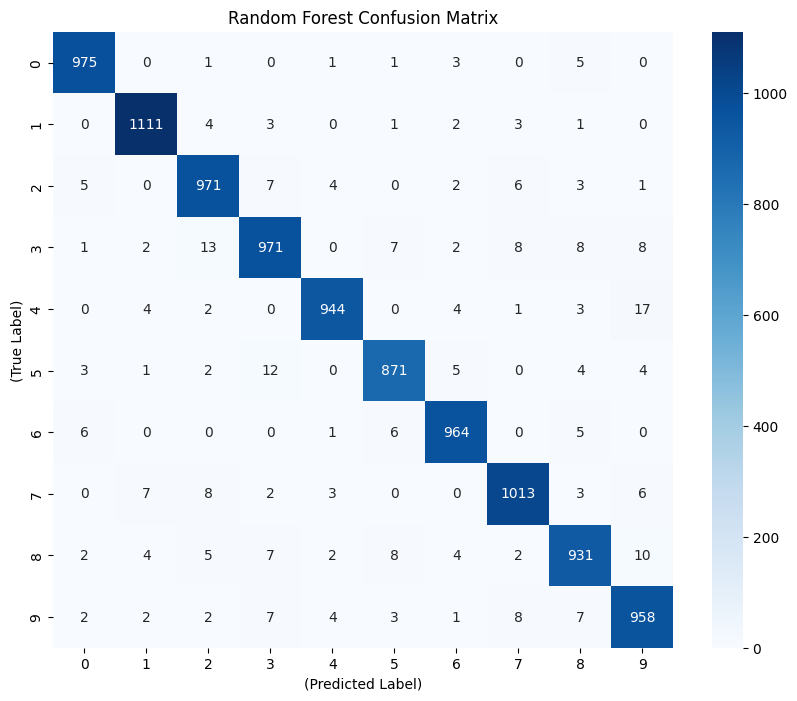

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))

sns.heatmap(conf_mx, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("(Predicted Label)")
plt.ylabel("(True Label)")
plt.title("Random Forest Confusion Matrix")
plt.show()

EXTRA TREES CLASSIFIER

In [7]:
# Extra trees classifier
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_clf = ExtraTreesClassifier(random_state=42)

print("Training Extra Trees...")
extra_trees_clf.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred_et = extra_trees_clf.predict(X_val)
val_accuracy_et = accuracy_score(y_val, y_val_pred_et)
print(f"Extra Trees Validation Accuracy: {val_accuracy_et:.4f}")

Training Extra Trees...
Extra Trees Validation Accuracy: 0.9731


In [8]:
# Extra trees train score
y_train_pred = extra_trees_clf.predict(X_train)
et_train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Extra trees train score: {et_train_accuracy}")

Extra trees train score: 1.0


In [9]:
# Accuracy, Precission, Recall, F1-score
precision = precision_score(y_val, y_val_pred_et, average='weighted')
recall = recall_score(y_val, y_val_pred_et, average='weighted')
f1 = f1_score(y_val, y_val_pred_et, average='weighted')

print(f"Accuracy:  {val_accuracy_et:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print(classification_report(y_val, y_val_pred_et))

Accuracy:  0.9731
Precision: 0.9731
Recall:    0.9731
F1-score:  0.9731
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       986
           1       0.99      0.99      0.99      1125
           2       0.97      0.97      0.97       999
           3       0.96      0.95      0.96      1020
           4       0.98      0.97      0.98       975
           5       0.98      0.97      0.97       902
           6       0.98      0.98      0.98       982
           7       0.98      0.98      0.98      1042
           8       0.96      0.96      0.96       975
           9       0.95      0.97      0.96       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



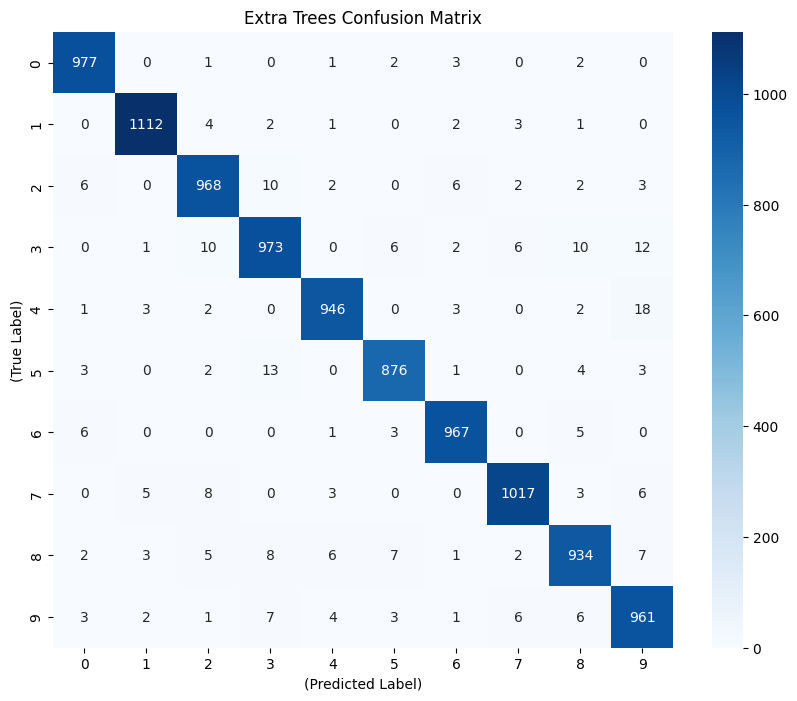

In [10]:
conf_mx_et = confusion_matrix(y_val, y_val_pred_et)
plt.figure(figsize=(10, 8))

sns.heatmap(conf_mx_et, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("(Predicted Label)")
plt.ylabel("(True Label)")
plt.title("Extra Trees Confusion Matrix")
plt.show()

SVM CLASSIFIER

In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42))
])

print("Training SVM...")
svm_clf.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred_svm = svm_clf.predict(X_val)
val_accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
print(f"SVM Validation Accuracy: {val_accuracy_svm:.4f}")

y_train_pred_svm = svm_clf.predict(X_train)
svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)
print(f"SVM Train Accuracy: {svm_train_accuracy:.4f}")

Training SVM...
SVM Validation Accuracy: 0.9722
SVM Train Accuracy: 0.9979


In [12]:
# Accuracy, Precission, Recall, F1-score
precision = precision_score(y_val, y_val_pred_svm, average='weighted')
recall = recall_score(y_val, y_val_pred_svm, average='weighted')
f1 = f1_score(y_val, y_val_pred_svm, average='weighted')

print(f"Accuracy:  {val_accuracy_svm:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print(classification_report(y_val, y_val_pred_svm))

Accuracy:  0.9722
Precision: 0.9724
Recall:    0.9722
F1-score:  0.9722
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       986
           1       0.99      0.98      0.99      1125
           2       0.97      0.97      0.97       999
           3       0.97      0.96      0.97      1020
           4       0.98      0.97      0.97       975
           5       0.97      0.97      0.97       902
           6       0.98      0.97      0.98       982
           7       0.93      0.98      0.96      1042
           8       0.97      0.95      0.96       975
           9       0.97      0.97      0.97       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



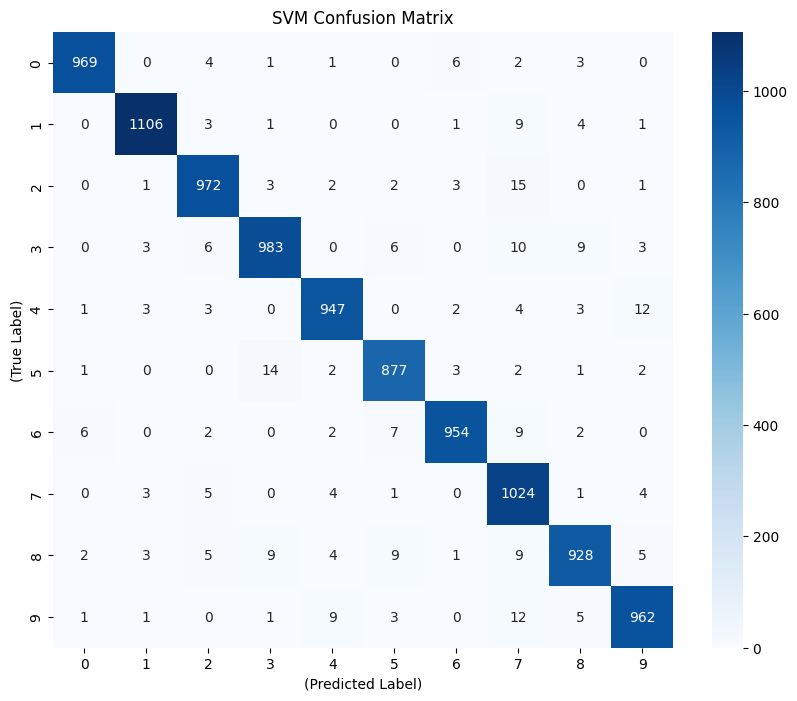

In [13]:
conf_mx_svm = confusion_matrix(y_val, y_val_pred_svm)
plt.figure(figsize=(10, 8))

sns.heatmap(conf_mx_svm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("(Predicted Label)")
plt.ylabel("(True Label)")
plt.title("SVM Confusion Matrix")
plt.show()

3. Combine them into an ensemble that outperforms each
individual classifier on the validation set, using soft or hard voting.

Ensemble Soft

In [14]:
from sklearn.ensemble import VotingClassifier

voting_clf_soft = VotingClassifier(
    estimators=[
        ('rf', forest_clf),
        ('et', extra_trees_clf),
        ('svm', svm_clf)   
    ],
    voting='soft'
)

print("Soft Voting...")
voting_clf_soft.fit(X_train, y_train)  # pass raw X_train — pipeline scales internally

y_val_pred_voting_soft = voting_clf_soft.predict(X_val)  # same here
val_accuracy_ensemble_soft = accuracy_score(y_val, y_val_pred_voting_soft)
print(f"Ensemble Soft Validation Accuracy: {val_accuracy_ensemble_soft:.4f}")

Soft Voting...
Ensemble Soft Validation Accuracy: 0.9817


In [15]:
# Ensemble train score
y_train_pred_ensemble_soft = voting_clf_soft.predict(X_train)
ensemble_train_accuracy_soft = accuracy_score(y_train, y_train_pred_ensemble_soft)
print(f"Ensemble train score: {ensemble_train_accuracy_soft}")

Ensemble train score: 1.0


In [16]:
# Accuracy, Precission, Recall, F1-score
precision = precision_score(y_val, y_val_pred_voting_soft, average='weighted')
recall = recall_score(y_val, y_val_pred_voting_soft, average='weighted')
f1 = f1_score(y_val, y_val_pred_voting_soft, average='weighted')

print(f"Accuracy:  {val_accuracy_ensemble_soft:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print(classification_report(y_val, y_val_pred_voting_soft))

Accuracy:  0.9817
Precision: 0.9817
Recall:    0.9817
F1-score:  0.9817
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       986
           1       0.99      0.99      0.99      1125
           2       0.98      0.98      0.98       999
           3       0.99      0.97      0.98      1020
           4       0.98      0.98      0.98       975
           5       0.98      0.98      0.98       902
           6       0.99      0.98      0.98       982
           7       0.98      0.99      0.98      1042
           8       0.97      0.97      0.97       975
           9       0.97      0.98      0.97       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



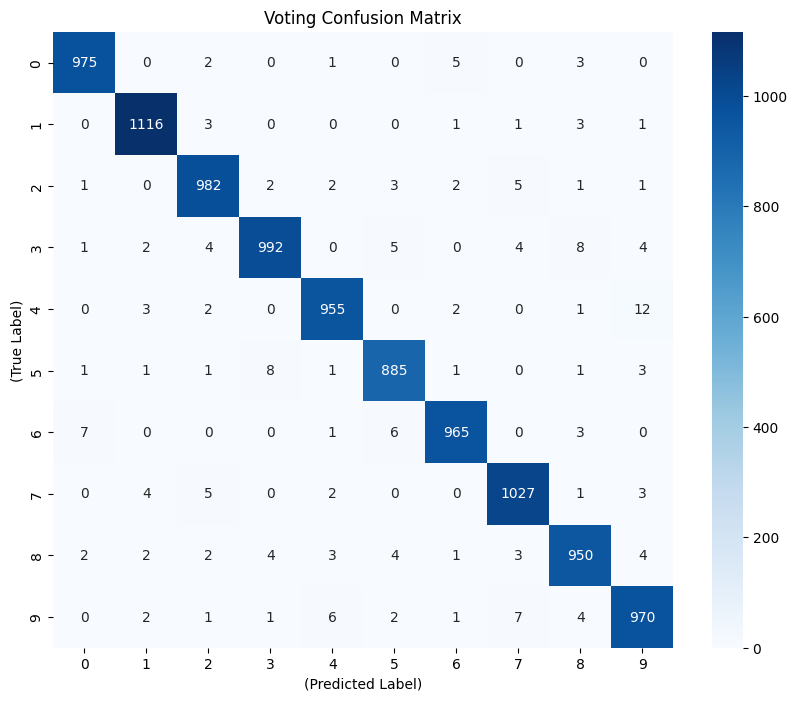

In [17]:
conf_mx_voting_soft = confusion_matrix(y_val, y_val_pred_voting_soft)
plt.figure(figsize=(10, 8))

sns.heatmap(conf_mx_voting_soft, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("(Predicted Label)")
plt.ylabel("(True Label)")
plt.title("Voting Confusion Matrix")
plt.show()

Ensemble hard

In [18]:
from sklearn.ensemble import VotingClassifier

voting_clf_hard = VotingClassifier(
    estimators=[
        ('rf', forest_clf),
        ('et', extra_trees_clf),
        ('svm', svm_clf) 
    ],
    voting='hard'
)

print("Hard Voting...")
voting_clf_hard.fit(X_train, y_train)

y_val_pred_voting_hard = voting_clf_hard.predict(X_val)
val_accuracy_ensemble_hard = accuracy_score(y_val, y_val_pred_voting_hard)
print(f"Ensemble Hard Validation Accuracy: {val_accuracy_ensemble_hard:.4f}")

Hard Voting...
Ensemble Hard Validation Accuracy: 0.9751


In [19]:
# Ensemble train score
y_train_pred_ensemble = voting_clf_hard.predict(X_train)
ensemble_train_accuracy = accuracy_score(y_train, y_train_pred_ensemble)
print(f"Ensemble train score: {ensemble_train_accuracy}")

Ensemble train score: 1.0


In [20]:
# Accuracy, Precission, Recall, F1-score
precision = precision_score(y_val, y_val_pred_voting_hard, average='weighted')
recall = recall_score(y_val, y_val_pred_voting_hard, average='weighted')
f1 = f1_score(y_val, y_val_pred_voting_hard, average='weighted')

print(f"Accuracy:  {val_accuracy_ensemble_hard:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print(classification_report(y_val, y_val_pred_voting_hard))

Accuracy:  0.9751
Precision: 0.9751
Recall:    0.9751
F1-score:  0.9751
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.99      0.99      0.99      1125
           2       0.97      0.98      0.97       999
           3       0.97      0.96      0.96      1020
           4       0.98      0.97      0.98       975
           5       0.98      0.97      0.98       902
           6       0.98      0.98      0.98       982
           7       0.98      0.98      0.98      1042
           8       0.97      0.96      0.96       975
           9       0.96      0.97      0.97       994

    accuracy                           0.98     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.98      0.98      0.98     10000



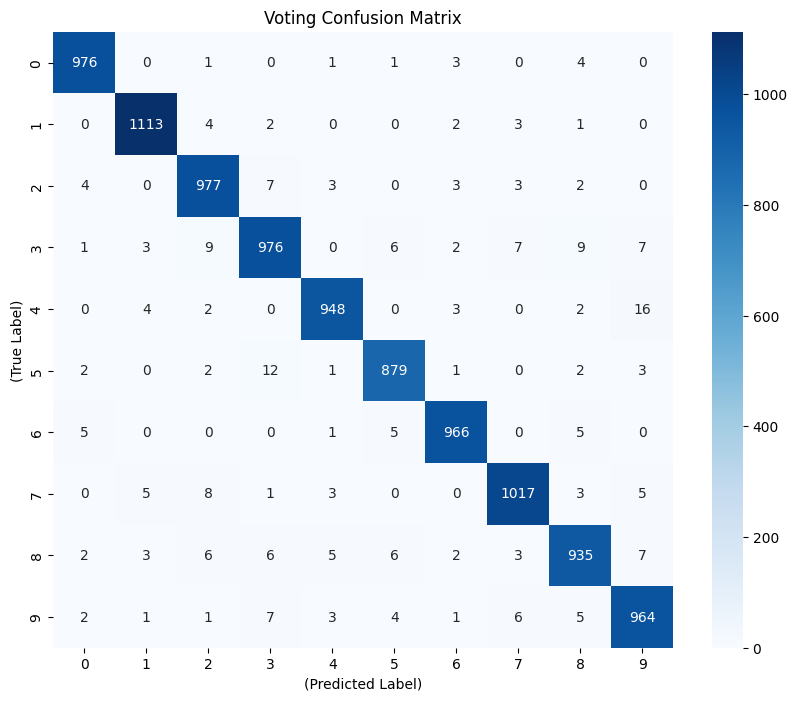

In [21]:
conf_mx_voting = confusion_matrix(y_val, y_val_pred_voting_hard)
plt.figure(figsize=(10, 8))

sns.heatmap(conf_mx_voting, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("(Predicted Label)")
plt.ylabel("(True Label)")
plt.title("Voting Confusion Matrix")
plt.show()

4. Try it on the test set.

In [23]:
from sklearn.metrics import classification_report

y_test_pred = voting_clf_soft.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"TEST SET RESULT: {test_accuracy:.4f}")

print("\nReport:")
print(classification_report(y_test, y_test_pred))

TEST SET RESULT: 0.9785

Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.98      0.99      0.99      1125
           2       0.98      0.98      0.98       999
           3       0.98      0.97      0.98      1020
           4       0.98      0.98      0.98       975
           5       0.98      0.97      0.98       902
           6       0.98      0.99      0.99       982
           7       0.98      0.98      0.98      1042
           8       0.97      0.97      0.97       975
           9       0.96      0.97      0.97       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [24]:
y_test_pred_rf = forest_clf.predict(X_test)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"TEST SET RESULT: {test_accuracy_rf:.4f}")

print("\nReport:")
print(classification_report(y_test, y_test_pred_rf))

TEST SET RESULT: 0.9657

Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       986
           1       0.98      0.98      0.98      1125
           2       0.96      0.97      0.96       999
           3       0.95      0.95      0.95      1020
           4       0.97      0.96      0.97       975
           5       0.97      0.96      0.97       902
           6       0.98      0.98      0.98       982
           7       0.97      0.97      0.97      1042
           8       0.95      0.95      0.95       975
           9       0.94      0.94      0.94       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [25]:
y_test_pred_rf = extra_trees_clf.predict(X_test)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"TEST SET RESULT: {test_accuracy_rf:.4f}")

print("\nReport:")
print(classification_report(y_test, y_test_pred_rf))

TEST SET RESULT: 0.9706

Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       986
           1       0.98      0.99      0.98      1125
           2       0.97      0.97      0.97       999
           3       0.96      0.96      0.96      1020
           4       0.98      0.97      0.97       975
           5       0.98      0.97      0.97       902
           6       0.98      0.99      0.98       982
           7       0.98      0.97      0.97      1042
           8       0.96      0.96      0.96       975
           9       0.94      0.95      0.95       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [26]:
y_test_pred_rf = svm_clf.predict(X_test)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"TEST SET RESULT: {test_accuracy_rf:.4f}")

print("\nReport:")
print(classification_report(y_test, y_test_pred_rf))

TEST SET RESULT: 0.9694

Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.98      0.99      0.98      1125
           2       0.97      0.97      0.97       999
           3       0.97      0.95      0.96      1020
           4       0.98      0.96      0.97       975
           5       0.97      0.96      0.97       902
           6       0.97      0.98      0.98       982
           7       0.93      0.97      0.95      1042
           8       0.98      0.96      0.97       975
           9       0.97      0.96      0.96       994

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

